In [14]:
import numpy as np
import scipy
import pandas as pd
import thinkbayes

In [15]:
class Pdf(object):
    """Represents a probability density function (PDF)"""

    def Density(self, x):
        """Evaluates this Pdf at x,
        Returns: float probability density"""

        raise thinkbayes.UnimplementedMethodException()

    def MakePmf(self, xs, name=''):
        """Makes a discrete version of this Pdf, evaluated at xs.
        xs: equally-spaced sequence of values
        Returns: new Pmf"""

        pmf = thinkbayes.Pmf(name=name)
        for x in xs:
            pmf.Set(x, self.Density(x))
        pmf.Normalize()
        return pmf

In [16]:
class EstimatedPdf(Pdf):
    def __init__(self, sample):
        self.kde = scipy.stats.gaussian_kde(sample)

    def Density(self,x):
        return self.kde.evaluate(x)

In [17]:
class Price(thinkbayes.Suite):
    """Represents hypotheses about the price of a showcase."""

    def __init__(self, pmf, player, name=""):
        """Constructs the suite.
        
        pmf: prior distribution of price
        player: player object
        name: string
        """

        thinkbayes.Suite.__init__(self, pmf, name=name)
        self.player = player

    def Likelihood(self, data, hypo):
        """Computes the likelihood of the data under the hypothesis.
        
        hypo: actual price
        data: the contestant's guess
        """

        price = hypo
        guess = data

        error = price - guess
        like = self.player.ErrorDensityGauss(error)

        return like


In [18]:
class Player(object):
    """Represents a player on The Price is Right."""

    n = 101
    price_xs = np.linspace(0, 75000, n)

    def __init__(self, prices, bids, diffs):
        """Construct the Player.
        Prices: sequence of prices
        bids: sequence of bids
        diffs: sequence of underness (negative means over)
        """

        self.pdf_price = EstimatedPdf(prices)
        self.pdf_diff = thinkbayes.MakeCdfFromList(diffs)

        mu = 0
        sigma = np.std(diffs)
        self.pdf_error_gauss = thinkbayes.GaussianPdf(mu, sigma)

        self.pdf_error_kde = EstimatedPdf(diffs)

    def ErrorDensityGauss(self, error):
        """Density of the given error in the distribution of error.
        
        error: how much the bid is under the actual price
        """
        return self.pdf_error_gauss.Density(error)

    def ErrorDensityKDE(self, error):
        return self.pdf_error_kde.Density(error)

    def MakeBeliefs(self, guess):
        """Makes a posterior distribution based on estimated price.
        Sets attributes prior and posterior.
        guess: what the player thinks the showcase is worth
        """

        pmf = self.PmfPrice()
        self.prior = Price(pmf, self, name='prior')
        self.posterior = self.prior.Copy(name='posterior')
        self.posterior.Update(guess)

    def PmfPrice(self):
        """Returns a new Pmf of prices.
        A discrete version of the estimated Pdf.
        """

        return self.pdf_price.MakePmf(self.price_xs)

In [20]:
df = pd.read_csv("showcases.2011.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df1 = df.copy()

df = pd.read_csv("showcases.2012.csv").T
df.columns = df.iloc[0]
df = df.iloc[1:].reset_index(drop=True)
df = df.loc[:, df.columns.notna()]
df = df.astype(float)
df2 = df.copy()

df3 = pd.concat([df1, df2], axis=0, ignore_index=True)

df3.head()

Unnamed: 0,Showcase 1,Showcase 2,Bid 1,Bid 2,Difference 1,Difference 2
0,50969.0,45429.0,42000.0,34000.0,8969.0,11429.0
1,21901.0,34061.0,14000.0,59900.0,7901.0,-25839.0
2,32815.0,53186.0,32000.0,45000.0,815.0,8186.0
3,44432.0,31428.0,27000.0,38000.0,17432.0,-6572.0
4,24273.0,22320.0,18750.0,23000.0,5523.0,-680.0


In [21]:
showcase1 = df3["Showcase 1"].dropna().values
bid1      = df3["Bid 1"].dropna().values
diff1     = df3["Difference 1"].dropna().values

In [22]:
player = Player(showcase1, bid1, diff1)

In [23]:
print(player.__dict__.keys())

dict_keys(['pdf_price', 'pdf_diff', 'pdf_error_gauss', 'pdf_error_kde'])


In [24]:
player.MakeBeliefs(guess=25000)

In [25]:
print(player.__dict__.keys())

dict_keys(['pdf_price', 'pdf_diff', 'pdf_error_gauss', 'pdf_error_kde', 'prior', 'posterior'])


In [26]:
print(player.posterior)

In [27]:
print(player.posterior.__dict__)

{'name': 'posterior', 'd': {0.0: array([1.12382028e-22]), 750.0: array([2.79816675e-21]), 1500.0: array([6.18374447e-20]), 2250.0: array([1.21330997e-18]), 3000.0: array([2.11442826e-17]), 3750.0: array([3.27410522e-16]), 4500.0: array([4.50680002e-15]), 5250.0: array([5.51744693e-14]), 6000.0: array([6.01093078e-13]), 6750.0: array([5.83095536e-12]), 7500.0: array([5.03980583e-11]), 8250.0: array([3.88388098e-10]), 9000.0: array([2.67065247e-09]), 9750.0: array([1.6398657e-08]), 10500.0: array([8.99906602e-08]), 11250.0: array([4.41736877e-07]), 12000.0: array([1.94137375e-06]), 12750.0: array([7.64655841e-06]), 13500.0: array([2.7021331e-05]), 14250.0: array([8.57748635e-05]), 15000.0: array([0.00024492]), 15750.0: array([0.00063014]), 16500.0: array([0.00146365]), 17250.0: array([0.00307666]), 18000.0: array([0.00587024]), 18750.0: array([0.01020382]), 19500.0: array([0.01623163]), 20250.0: array([0.02375956]), 21000.0: array([0.03221392]), 21750.0: array([0.0407681]), 22500.0: arra

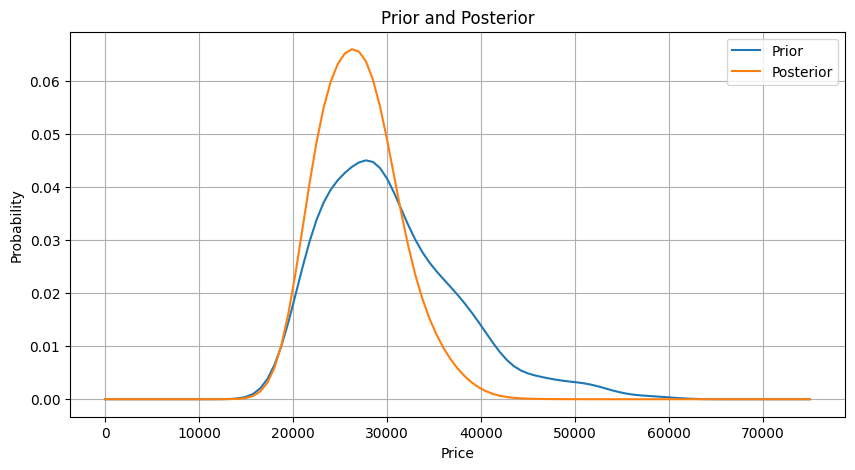

In [29]:
import matplotlib.pyplot as plt

# x軸：価格
xs = player.price_xs

# Prior
prior_y = np.array([
    player.prior.Prob(price).item()
    for price in xs
])

# Posterior
posterior_y = np.array([
    player.posterior.Prob(price).item()
    for price in xs
])

plt.figure(figsize=(10, 5))

plt.plot(xs, prior_y, label="Prior")
plt.plot(xs, posterior_y, label="Posterior")

plt.xlabel("Price")
plt.ylabel("Probability")
plt.title("Prior and Posterior")
plt.legend()
plt.grid()
plt.show()

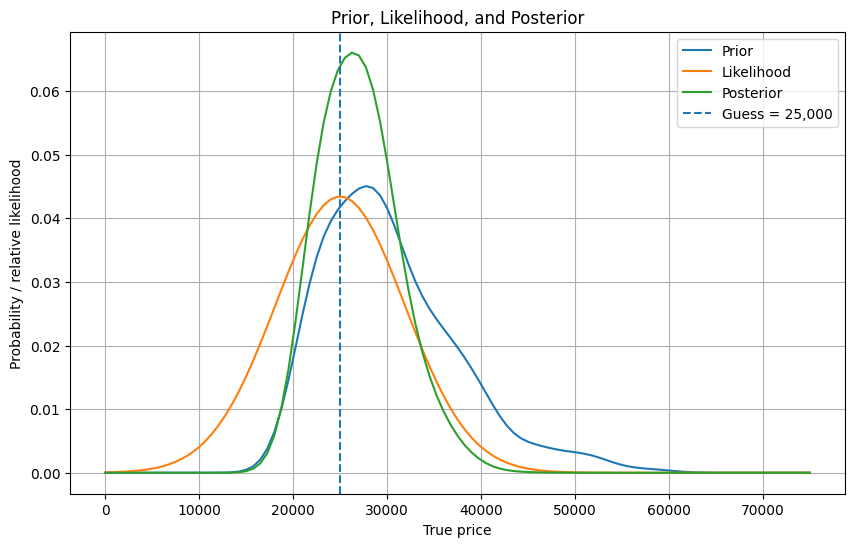

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# 今回のGuess
guess = 25000

# 横軸：真の価格
xs = player.price_xs

# -------------------------
# 1. Prior
# -------------------------
prior = np.array([
    player.prior.Prob(x).item()
    for x in xs
])

# -------------------------
# 2. Likelihood
# -------------------------
# 真の価格 x のとき、
# Guess=25000 との誤差を計算
errors = xs - guess

likelihood = np.array([
    player.pdf_error_gauss.Density(error).item()
    for error in errors
])

# グラフ比較用に正規化
likelihood = likelihood / likelihood.sum()

# -------------------------
# 3. Posterior
# -------------------------
posterior = np.array([
    player.posterior.Prob(x).item()
    for x in xs
])

# -------------------------
# グラフ
# -------------------------
plt.figure(figsize=(10, 6))

plt.plot(xs, prior, label="Prior")
plt.plot(xs, likelihood, label="Likelihood")
plt.plot(xs, posterior, label="Posterior")

plt.axvline(guess, linestyle="--", label="Guess = 25,000")

plt.xlabel("True price")
plt.ylabel("Probability / relative likelihood")
plt.title("Prior, Likelihood, and Posterior")

plt.legend()
plt.grid()
plt.show()